# 🎓 Student Performance - Machine Learning Project

Dans ce projet, nous analysons les performances des étudiants à l'aide de différentes techniques de Machine Learning.

L'objectif est d'étudier les facteurs influençant les résultats scolaires et d'appliquer des méthodes de :

Régression pour prédire les notes des étudiants ;
Classification pour prédire la réussite ou l'échec scolaire ;
Clustering pour identifier différents groupes d'étudiants ayant des profils similaires.

Le dataset utilisé provient de Kaggle et contient des informations démographiques ainsi que les résultats académiques des étudiants.

## 1. Chargement et exploration du dataset :
Dans cette partie, nous chargeons le dataset et analysons sa structure, ses colonnes et ses statistiques.

In [49]:
import pandas as pd

# Charger le dataset
df = pd.read_csv("StudentsPerformance.csv")

# Afficher les 5 premières lignes
print(df.head())

# Informations générales
print(df.info())

# Statistiques descriptives
print(df.describe())

# Vérification des valeurs manquantes
print("\nValeurs manquantes :")
print(df.isnull().sum())

# Vérification des doublons
print("\nNombre de doublons :", df.duplicated().sum())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

## 2. Visualisation des données :
Cette étape permet d'explorer graphiquement la distribution des données et les relations entre les variables.

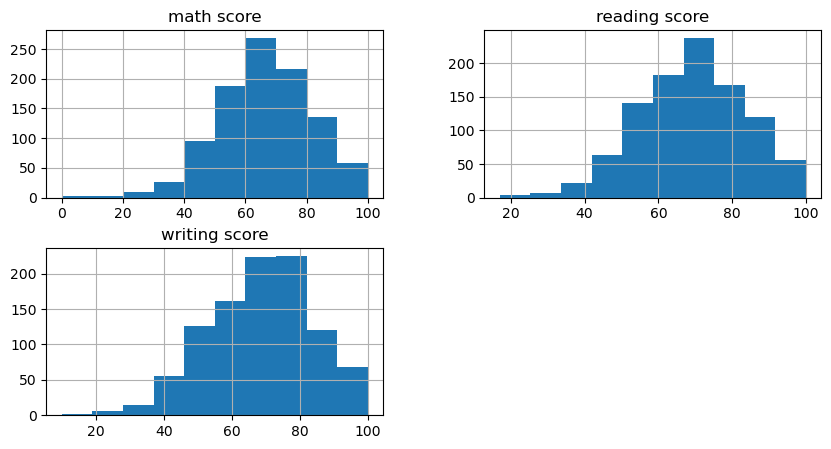

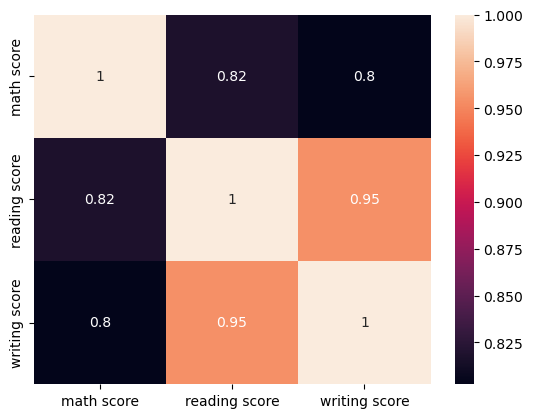

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
df[['math score', 'reading score', 'writing score']].hist(figsize=(10,5))
plt.show()

sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True)
plt.show()

## 3. Prétraitement des données : Encodage des variables catégorielles

In [51]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

   math score  reading score  writing score  gender_male  \
0          72             72             74        False   
1          69             90             88        False   
2          90             95             93        False   
3          47             57             44         True   
4          76             78             75         True   

   race/ethnicity_group B  race/ethnicity_group C  race/ethnicity_group D  \
0                    True                   False                   False   
1                   False                    True                   False   
2                    True                   False                   False   
3                   False                   False                   False   
4                   False                    True                   False   

   race/ethnicity_group E  parental level of education_bachelor's degree  \
0                   False                                           True   
1                   Fals

# 4. Supervised Learning :

## RÉGRESSION :

#### Définir X et y :

In [92]:
# variables explicatives
X = df_encoded.drop("math score", axis=1)

# variable cible
y = df_encoded["math score"]

#### Split :

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Regression Models:

### Modèle 1 : Linear Regression

In [94]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

### Modèle 2 : Decision Tree Regressor

In [95]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor()
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

### Modèle 3 : KNN Regressor

In [96]:
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor()
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

### Modèle 4 : Random Forest Regressor

In [97]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

### Modèle 5 : Ridge

In [98]:
from sklearn.linear_model import Ridge

model_ridge = Ridge()

model_ridge.fit(X_train,y_train)

y_pred_ridge = model_ridge.predict(X_test)

### Modèle 6 : Lasso

In [99]:
from sklearn.linear_model import Lasso

model_lasso = Lasso()

model_lasso.fit(X_train,y_train)

y_pred_lasso = model_lasso.predict(X_test)

### Modèle 7 : ElasticNet

In [100]:
from sklearn.linear_model import ElasticNet

model_elastic = ElasticNet()

model_elastic.fit(X_train,y_train)

y_pred_elastic = model_elastic.predict(X_test)

## Évaluation :

##### # R2:

In [61]:
from sklearn.metrics import mean_squared_error, r2_score

print("LR R2:", r2_score(y_test, y_pred_lr))
print("DT R2:", r2_score(y_test, y_pred_dt))
print("KNN R2:", r2_score(y_test, y_pred_knn))
print("RF R2:", r2_score(y_test, y_pred_rf))

LR R2: 0.8804332983749564
DT R2: 0.738409556403757
KNN R2: 0.6959764673393102
RF R2: 0.8491990721184489


In [62]:
print("Ridge R2:", r2_score(y_test,y_pred_ridge))
print("Lasso R2:", r2_score(y_test,y_pred_lasso))
print("ElasticNet R2:", r2_score(y_test,y_pred_elastic))

Ridge R2: 0.8803261594918251
Lasso R2: 0.8336033203865771
ElasticNet R2: 0.7631620059532643


#### #MSE:

In [63]:
print("LR MSE:", mean_squared_error(y_test, y_pred_lr))
print("DT MSE:", mean_squared_error(y_test, y_pred_dt))
print("KNN MSE:", mean_squared_error(y_test, y_pred_knn))
print("RF MSE:", mean_squared_error(y_test, y_pred_rf))

LR MSE: 29.095169866715494
DT MSE: 63.655
KNN MSE: 73.98060000000001
RF MSE: 36.69565650921202


In [64]:
print("Ridge MSE:", mean_squared_error(y_test,y_pred_ridge))
print("Lasso MSE:", mean_squared_error(y_test,y_pred_lasso))
print("ElasticNet MSE:", mean_squared_error(y_test,y_pred_elastic))

Ridge MSE: 29.12124087111446
Lasso MSE: 40.49070178244294
ElasticNet MSE: 57.63177853054218


# CLASSIFICATION :

### Créer la cible :

In [65]:
df['result'] = df['math score'] >= 50

### définir X et y :

In [101]:
X = df_encoded.drop("math score", axis=1)
y = df['result']

### Split :

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Classification Models:

### Modèle 1: DecisionTreeClassifier

In [68]:
from sklearn.tree import DecisionTreeClassifier

clf_dt = DecisionTreeClassifier(max_depth=5)
clf_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Modèle 2: KNeighborsClassifier

In [69]:
from sklearn.neighbors import KNeighborsClassifier

clf_knn = KNeighborsClassifier()
clf_knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Modèle 3: LogisticRegression

In [103]:
from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Modèle 4: RandomForestClassifier

In [70]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(random_state=42)
clf_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Modèle 5 : SVM

In [71]:
from sklearn.svm import SVC

clf_svm = SVC()

clf_svm.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Modèle 6 : Perceptron

In [72]:
from sklearn.linear_model import Perceptron

clf_perc = Perceptron()

clf_perc.fit(X_train,y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


### Modèle 7 : AdaBoost

In [73]:
from sklearn.ensemble import AdaBoostClassifier

clf_ada = AdaBoostClassifier()

clf_ada.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


### Modèle 8 : Gradient Boosting

In [74]:
from sklearn.ensemble import GradientBoostingClassifier

clf_gb = GradientBoostingClassifier()

clf_gb.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Modèle 9 : Bagging

In [75]:
from sklearn.ensemble import BaggingClassifier

clf_bag = BaggingClassifier()

clf_bag.fit(X_train,y_train)

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


## Évaluation :

In [76]:
from sklearn.metrics import accuracy_score

print("DT:", accuracy_score(y_test, clf_dt.predict(X_test)))
print("KNN:", accuracy_score(y_test, clf_knn.predict(X_test)))
print("LR:", accuracy_score(y_test, clf_lr.predict(X_test)))
print("RF:", accuracy_score(y_test, clf_rf.predict(X_test)))

DT: 0.93
KNN: 0.87
LR: 0.96
RF: 0.94


In [77]:
print("SVM:", accuracy_score(y_test,clf_svm.predict(X_test)))

print("Perceptron:",
      accuracy_score(y_test,clf_perc.predict(X_test)))

print("AdaBoost:",
      accuracy_score(y_test,clf_ada.predict(X_test)))

print("Gradient Boosting:",
      accuracy_score(y_test,clf_gb.predict(X_test)))

print("Bagging:",
      accuracy_score(y_test,clf_bag.predict(X_test)))

SVM: 0.88
Perceptron: 0.86
AdaBoost: 0.935
Gradient Boosting: 0.935
Bagging: 0.925


## 5. Optimisation des hyperparamètres (Random Search) :

In [78]:
from sklearn.model_selection import RandomizedSearchCV

params = {
'n_estimators':[50,100,200],
'max_depth':[3,5,10,None]
}

search = RandomizedSearchCV(
RandomForestClassifier(),
params,
cv=5
)

search.fit(X_train,y_train)

print(search.best_params_)

{'n_estimators': 200, 'max_depth': 5}


# 6. Matrice de confusion :

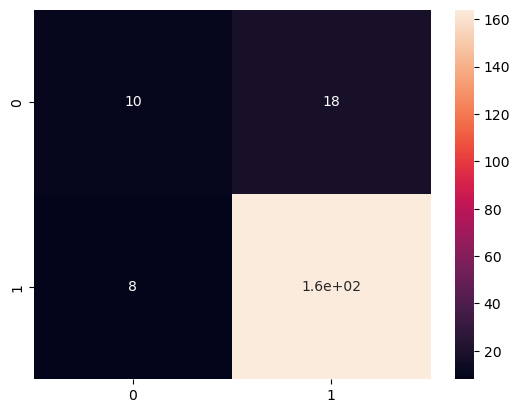

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, clf_knn.predict(X_test))
sns.heatmap(cm, annot=True)
plt.show()

### Classification Report

In [80]:
from sklearn.metrics import classification_report

print(
classification_report(
y_test,
clf_rf.predict(X_test)
))

              precision    recall  f1-score   support

       False       0.83      0.71      0.77        28
        True       0.95      0.98      0.97       172

    accuracy                           0.94       200
   macro avg       0.89      0.85      0.87       200
weighted avg       0.94      0.94      0.94       200



## 7. Validation croisée K-Fold

In [81]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
clf_rf,
X,
y,
cv=5
)

print(scores)
print(scores.mean())

[0.905 0.915 0.935 0.895 0.91 ]
0.9119999999999999


## Leave-One-Out

In [83]:
# Validation croisée Leave-One-Out
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

scores_loo = cross_val_score(
    clf_rf,
    X,
    y,
    cv=loo
)

print("Leave-One-Out Mean Accuracy:", scores_loo.mean())

Leave-One-Out Mean Accuracy: 0.916


# 8. Unsupervised Learning  :

## 1. KMeans :

In [84]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# prendre seulement les scores
X_cluster = df[['math score', 'reading score', 'writing score']]

# normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# appliquer K-means (3 groupes)
kmeans = KMeans(
n_clusters=3,
init='k-means++',
random_state=42
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# afficher
print(df[['math score','reading score','writing score','cluster']].head())

   math score  reading score  writing score  cluster
0          72             72             74        0
1          69             90             88        2
2          90             95             93        2
3          47             57             44        1
4          76             78             75        2


##  Visualisation des clusters :

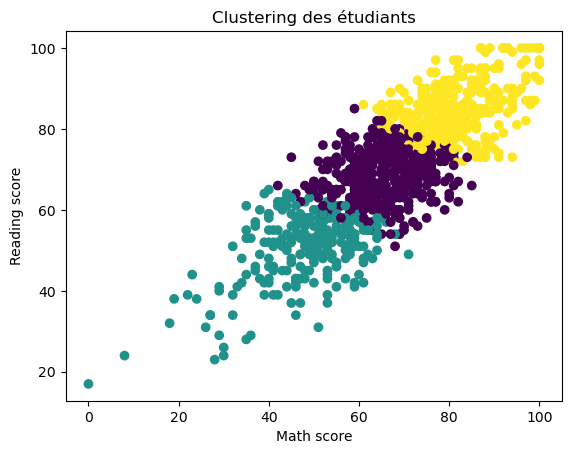

In [85]:
import matplotlib.pyplot as plt

plt.scatter(df['math score'], df['reading score'], c=df['cluster'])
plt.xlabel("Math score")
plt.ylabel("Reading score")
plt.title("Clustering des étudiants")
plt.show()

## Bisecting K-Means

In [104]:
from sklearn.cluster import BisectingKMeans

bk = BisectingKMeans(
n_clusters=3,
random_state=42
)

df['bisect_cluster'] = bk.fit_predict(X_scaled)

### Visualisation :

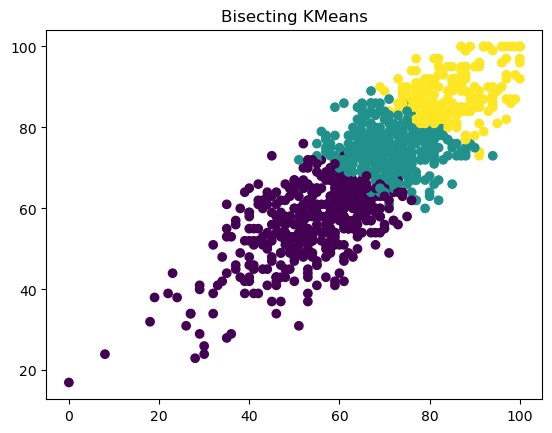

In [87]:
plt.scatter(
df['math score'],
df['reading score'],
c=df['bisect_cluster']
)

plt.title("Bisecting KMeans")
plt.show()

# 2. DBSCAN :

In [88]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


X_cluster = df[['math score', 'reading score', 'writing score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

dbscan = DBSCAN(eps=1.5, min_samples=5)

# clustering
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

### visualisation :

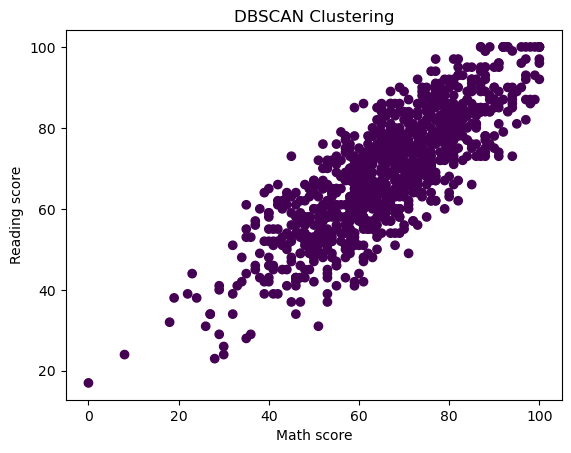

In [89]:
plt.scatter(
    df['math score'],
    df['reading score'],
    c=df['dbscan_cluster']
)

plt.xlabel("Math score")
plt.ylabel("Reading score")
plt.title("DBSCAN Clustering")
plt.show()

# 3. Hierarchical Clustering :

In [90]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

hc = AgglomerativeClustering(n_clusters=3)

df['hc_cluster'] = hc.fit_predict(X_scaled)

### visualisation :

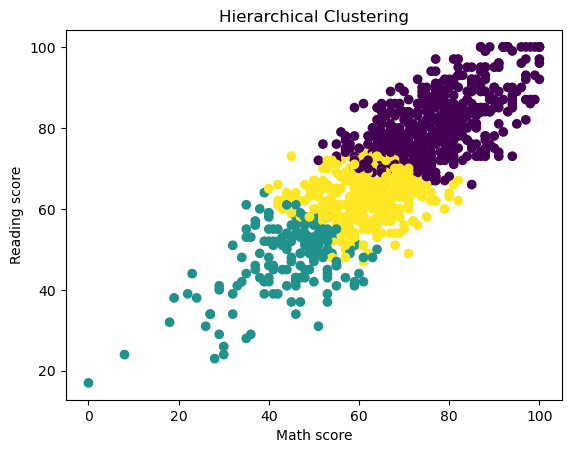

In [91]:
plt.scatter(
    df['math score'],
    df['reading score'],
    c=df['hc_cluster']
)

plt.xlabel("Math score")
plt.ylabel("Reading score")
plt.title("Hierarchical Clustering")
plt.show()

# Conclusion

Les résultats obtenus montrent que les techniques de Machine Learning permettent de prédire efficacement les performances scolaires et d'identifier 
différents profils d'étudiants à partir des données disponibles.